In [1]:
pip install transformers

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "nlptown/bert-base-multilingual-uncased-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print("BERT model loaded successfully!")

C:\ProgramData\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|███████████████████████| 201/201 [00:00<00:00, 284.90it/s, Materializing param=classifier.weight]


BERT model loaded successfully!


In [6]:
model.eval()
print("Model set to evaluation mode.")

Model set to evaluation mode.


In [7]:
def predict_sentiment(text):
    
    
    text = str(text)
    
    
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )
    
    
    with torch.no_grad():
     outputs = model(**inputs)
    
   
    prediction = torch.argmax(outputs.logits).item()
    
   
    if prediction <= 1:
        return "Negative"
    elif prediction == 2:
        return "Neutral"
    else:
        return "Positive"

In [8]:
print(predict_sentiment("This is amazing! I love it 😍"))
print(predict_sentiment("This is terrible and useless."))
print(predict_sentiment("It is okay, nothing special."))

Positive
Negative
Neutral


In [9]:
import pandas as pd
import os

file_path = "Reddit_Emoji_Dataset_10000.xlsx"  


file_extension = os.path.splitext(file_path)[1].lower()

if file_extension == ".csv":
    df = pd.read_csv(file_path)

elif file_extension in [".xlsx", ".xls"]:
    df = pd.read_excel(file_path)

elif file_extension == ".json":
    df = pd.read_json(file_path)

else:
    raise ValueError("Unsupported file format!")

print("Dataset loaded successfully!")
print("Detected file type:", file_extension)
print("Columns:", df.columns)

Dataset loaded successfully!
Detected file type: .xlsx
Columns: Index(['id', 'subreddit', 'body'], dtype='object')


In [10]:
possible_text_columns = ['body', 'text', 'comment', 'content', 'title', 'message', 'statement']

text_column = None

for col in df.columns:
    if col.lower() in possible_text_columns:
        text_column = col
        break

if text_column is None:
    raise ValueError("No suitable text column found in dataset!")

print("Detected text column:", text_column)

Detected text column: body


In [11]:
df = df.dropna(subset=[text_column])
print("Missing values removed.")

Missing values removed.


In [12]:
df = df.head(200)  

df["sentiment"] = df[text_column].apply(predict_sentiment)

print(df[[text_column, "sentiment"]].head())

                           body sentiment
0     This is fantastic work 👏🔥  Positive
1           It's okay I guess 🙂   Neutral
2          Not bad, not great 😶   Neutral
3  Average experience overall 😐   Neutral
4     Nothing special here 🤷‍♂️   Neutral


In [13]:
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
Positive    78
Negative    71
Neutral     51
Name: count, dtype: int64


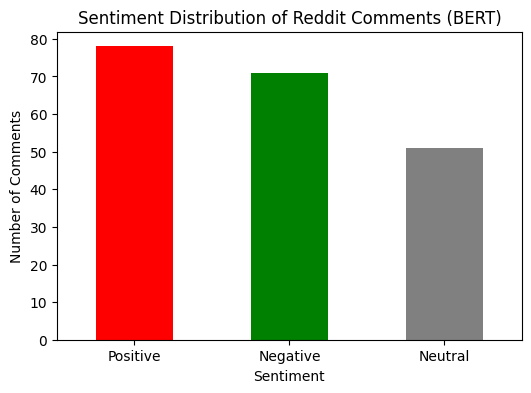

In [14]:
import matplotlib.pyplot as plt

sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar', color=['red','green','gray'])
plt.title("Sentiment Distribution of Reddit Comments (BERT)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

plt.xticks(rotation=0)
plt.show()

In [15]:
sentiment_counts = df["sentiment"].value_counts()
sentiment_percent = df["sentiment"].value_counts(normalize=True) * 100

print("Counts:\n", sentiment_counts)
print("\nPercentages:\n", sentiment_percent)

Counts:
 sentiment
Positive    78
Negative    71
Neutral     51
Name: count, dtype: int64

Percentages:
 sentiment
Positive    39.0
Negative    35.5
Neutral     25.5
Name: proportion, dtype: float64


In [16]:
dominant = sentiment_counts.idxmax()
print(f"Majority of Reddit posts show {dominant} sentiment.")

Majority of Reddit posts show Positive sentiment.


🔹 Sentiment Percentage Comparison
           Subreddit A (%)  Subreddit B (%)
sentiment                                  
Negative              64.0             49.5
Neutral               18.5             21.5
Positive              17.5             29.0


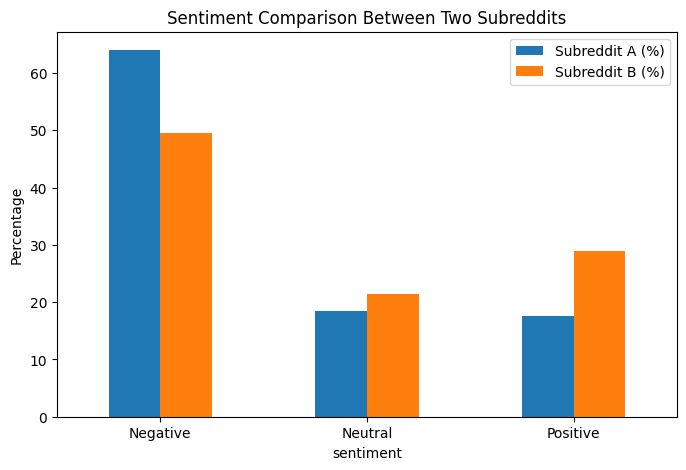

In [17]:
 # ===============================================
 # TWO SUBREDDIT SENTIMENT COMPARISON
 # ===============================================

import matplotlib.pyplot as plt

def process_dataset(df):
    possible_text_columns = ['body','text','comment','content','title','message','statement']
    
    text_column = None
    for col in df.columns:
        if col.lower() in possible_text_columns:
            text_column = col
            break
    
    if text_column is None:
        raise ValueError("No suitable text column found in dataset!")
    
    df = df.dropna(subset=[text_column])
    df = df.head(200) 
    
    df["sentiment"] = df[text_column].apply(predict_sentiment)
    
    sentiment_counts = df["sentiment"].value_counts()
    sentiment_percent = df["sentiment"].value_counts(normalize=True) * 100
    
    return sentiment_counts, sentiment_percent


# 🔹 Load First Subreddit Dataset
df1 = pd.read_csv("Combined Data.csv")   

# 🔹 Load Second Subreddit Dataset
df2 = pd.read_csv("kaggle_RC_2019-05.csv")   


# 🔹 Process both datasets
counts1, percent1 = process_dataset(df1)
counts2, percent2 = process_dataset(df2)


# 🔹 Create Comparison Table
comparison_df = pd.DataFrame({
    "Subreddit A (%)": percent1,
    "Subreddit B (%)": percent2
}).fillna(0)

print("🔹 Sentiment Percentage Comparison")
print(comparison_df)


# 🔹 Plot Comparison Graph
comparison_df.plot(kind='bar', figsize=(8,5))
plt.title("Sentiment Comparison Between Two Subreddits")
plt.xticks(rotation=0)
plt.ylabel("Percentage")
plt.show()